In [1]:
from typing import Dict, NamedTuple

import torch
import torch.nn as nn

In [2]:
class Context(NamedTuple):
    """Context container for conditioning information"""

    embedding_2d: torch.Tensor  # Shape: (batch_size, embed_dim, height, width)


TensorDict = Dict[str, torch.Tensor]


class SimpleConditionalLayerNorm(nn.Module):
    """
    Simplified Conditional Layer Normalization with 2D noise conditioning.
    Takes input of shape (batch_size, channels, height, width).
    """

    def __init__(
        self,
        n_channels: int,
        embed_dim: int,
        epsilon: float = 1e-5,
    ):
        super(SimpleConditionalLayerNorm, self).__init__()
        self.n_channels = n_channels
        self.embed_dim = embed_dim
        self.epsilon = epsilon

        # 2D conditioning layers
        self.W_scale_2d = nn.Conv2d(embed_dim, n_channels, kernel_size=1, bias=False)
        self.W_bias_2d = nn.Conv2d(embed_dim, n_channels, kernel_size=1, bias=False)

        # Layer norm without affine parameters
        self.norm = nn.LayerNorm(
            n_channels,
            eps=epsilon,
            elementwise_affine=False,
        )

        self.reset_parameters()

    def reset_parameters(self):
        torch.nn.init.constant_(self.W_scale_2d.weight, 0.0)
        torch.nn.init.constant_(self.W_bias_2d.weight, 0.0)

    def forward(self, x: torch.Tensor, context: Context) -> torch.Tensor:
        """
        Args:
            x: Input tensor of shape (batch_size, channels, height, width)
            context: Context containing embedding_2d of shape (batch_size, embed_dim, height, width)

        Returns:
            Normalized tensor of shape (batch_size, channels, height, width)
        """
        scale = 1.0 + self.W_scale_2d(context.embedding_2d)
        bias = self.W_bias_2d(context.embedding_2d)

        # Normalize independently per spatial location
        x = x.permute(0, 2, 3, 1)  # (batch_size, height, width, channels)
        x_norm = self.norm(x)
        x_norm = x_norm.permute(
            0, 3, 1, 2
        )  # Back to (batch_size, channels, height, width)

        return x_norm * scale + bias


class SimpleConditionalInstanceNorm(nn.Module):
    """
    Simplified Conditional Instance Normalization with 2D noise conditioning.
    Takes input of shape (batch_size, channels, height, width).
    """

    def __init__(
        self,
        n_channels: int,
        embed_dim: int,
        epsilon: float = 1e-5,
    ):
        super(SimpleConditionalInstanceNorm, self).__init__()
        self.n_channels = n_channels
        self.embed_dim = embed_dim
        self.epsilon = epsilon

        # 2D conditioning layers
        self.W_scale_2d = nn.Conv2d(embed_dim, n_channels, kernel_size=1, bias=False)
        self.W_bias_2d = nn.Conv2d(embed_dim, n_channels, kernel_size=1, bias=False)

        # Layer norm without affine parameters
        self.norm = nn.InstanceNorm2d(
            n_channels,
            eps=epsilon,
        )

        self.reset_parameters()

    def reset_parameters(self):
        torch.nn.init.constant_(self.W_scale_2d.weight, 0.0)
        torch.nn.init.constant_(self.W_bias_2d.weight, 0.0)

    def forward(self, x: torch.Tensor, context: Context) -> torch.Tensor:
        """
        Args:
            x: Input tensor of shape (batch_size, channels, height, width)
            context: Context containing embedding_2d of shape (batch_size, embed_dim, height, width)

        Returns:
            Normalized tensor of shape (batch_size, channels, height, width)
        """
        scale = 1.0 + self.W_scale_2d(context.embedding_2d)
        bias = self.W_bias_2d(context.embedding_2d)
        x_norm = self.norm(x)

        return x_norm * scale + bias


class NoiseConditionedNet(nn.Module):
    """
    A network using noise-conditioned layer normalization for ensemble predictions.
    """

    def __init__(
        self,
        input_channels: int,
        hidden_channels: int,
        embed_dim: int,
        output_channels: int,
        n_ensemble: int = 2,
    ):
        super(NoiseConditionedNet, self).__init__()

        self.input_conv = nn.Conv2d(
            input_channels, hidden_channels, kernel_size=3, padding=1
        )
        # self.cond_norm = SimpleConditionalLayerNorm(hidden_channels, embed_dim)
        self.cond_norm = SimpleConditionalInstanceNorm(hidden_channels, embed_dim)
        self.output_conv = nn.Conv2d(
            hidden_channels, output_channels, kernel_size=3, padding=1
        )
        self.activation = nn.ReLU()
        self.embed_dim = embed_dim
        self.n_ensemble = n_ensemble

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass generating multiple samples for ensemble prediction.

        Args:
            x: Input tensor of shape (batch_size, channels, height, width)

        Returns:
            Predictions tensor of shape (batch_size, n_ensemble, channels, height, width)
        """
        batch_size = x.shape[0]
        device = x.device
        dtype = x.dtype

        # Generate multiple predictions for ensemble
        predictions = []
        for _ in range(self.n_ensemble):
            # Generate random noise conditioning
            noise = torch.randn(
                [batch_size, self.embed_dim, *x.shape[-2:]], device=device, dtype=dtype
            )
            context = Context(embedding_2d=noise)

            # Forward pass
            h = self.input_conv(x)
            h = self.cond_norm(h, context)
            h = self.activation(h)
            pred = self.output_conv(h)
            predictions.append(pred)

        # Stack predictions along ensemble dimension
        return torch.stack(predictions, dim=1)


# Deterministic Model
class Net(nn.Module):
    """
    A network.
    """

    def __init__(
        self,
        input_channels: int,
        hidden_channels: int,
        embed_dim: int,
        output_channels: int,
    ):
        super(Net, self).__init__()

        self.input_conv = nn.Conv2d(
            input_channels, hidden_channels, kernel_size=3, padding=1
        )
        # self.norm = nn.LayerNorm(hidden_channels, eps=1e-5, elementwise_affine=False)
        self.norm = nn.InstanceNorm2d(hidden_channels, eps=1e-5)
        self.output_conv = nn.Conv2d(
            hidden_channels, output_channels, kernel_size=3, padding=1
        )
        self.activation = nn.ReLU()
        self.embed_dim = embed_dim

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.

        Args:
            x: Input tensor of shape (batch_size, channels, height, width)

        Returns:
            Predictions tensor of shape (batch_size, channels, height, width)
        """
        # Forward pass
        h = self.input_conv(x)
        h = h.permute(0, 2, 3, 1)  # (batch_size, height, width, channels)
        h = self.norm(h)
        h = h.permute(0, 3, 1, 2)
        h = self.activation(h)
        pred = self.output_conv(h)

        return pred

In [3]:
def crps_loss(
    predictions: torch.Tensor,
    targets: torch.Tensor,
    alpha: float = 0.95,
) -> torch.Tensor:
    """
    Compute the CRPS loss for ensemble predictions.

    Args:
        predictions: Tensor of shape (batch_size, n_ensemble, channels, height, width)
        targets: Tensor of shape (batch_size, channels, height, width)
        alpha: Parameter for "almost fair" CRPS (default: 0.95)

    Returns:
        CRPS loss value
    """
    if predictions.shape[1] != 2:
        raise NotImplementedError(
            "CRPS loss is written specifically for 2 samples, "
            f"got {predictions.shape[1]} samples"
        )

    # Compute epsilon for "almost fair" CRPS
    epsilon = (1 - alpha) / 2

    # Compute target term: E[|X - y|]
    target_term = torch.abs(predictions - targets.unsqueeze(1)).mean(dim=1)

    # Compute internal term: -1/2 E[|X - X'|]
    internal_term = -0.5 * torch.abs(predictions[:, 0] - predictions[:, 1])

    # Combine terms with epsilon adjustment
    loss = (target_term + (1 - epsilon) * internal_term).mean()

    return loss


def mse_loss(predictions: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    return (predictions - targets).pow(2).mean()

In [4]:
def train_step(
    model: NoiseConditionedNet,
    optimizer: torch.optim.Optimizer,
    inputs: torch.Tensor,
    targets: torch.Tensor,
    mse: bool = False,
) -> float:
    """Perform a single training step."""
    optimizer.zero_grad()

    # Forward pass
    predictions = model(inputs)

    # Compute loss
    if mse:
        loss = mse_loss(predictions.mean(dim=1), targets)
    else:
        loss = crps_loss(predictions, targets)

    # Backward pass
    loss.backward()
    optimizer.step()

    return loss.item()

In [5]:
def generate_controlled_toy_data(
    batch_size: int = 32,
    height: int = 32,
    width: int = 32,
    truth_amount: float = 0.8,
    random_amount: float = 0.2,
    seed: int = None,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Generate toy data with controlled predictability for training probabilistic models.

    Args:
        batch_size: Number of samples in batch
        height: Height of 2D data
        width: Width of 2D data
        truth_amount: Amount of predictable signal (higher = more predictable)
        random_amount: Amount of random noise (higher = more uncertainty)
        seed: Random seed for reproducibility

    Returns:
        tuple of:
            inputs: Tensor of shape (batch_size, 1, height, width)
            targets: Tensor of shape (batch_size, 1, height, width)
    """
    if seed is not None:
        torch.manual_seed(seed)

    # Generate predictable component - use spatial patterns
    x = torch.linspace(-4, 4, width)
    y = torch.linspace(-4, 4, height)
    xx, yy = torch.meshgrid(x, y, indexing="ij")

    predictable_pattern = torch.sin(xx[None, None]) * torch.cos(yy[None, None])
    predictable_pattern = predictable_pattern.expand(batch_size, 1, height, width)

    # Add batch dimension and scale to [-1, 1]
    predictable_pattern = predictable_pattern / predictable_pattern.abs().max()

    # Generate input features (slightly corrupted version of predictable pattern)
    inputs = predictable_pattern + 0.1 * torch.randn_like(predictable_pattern)

    # Generate targets with controlled randomness
    targets = (
        truth_amount * predictable_pattern  # Predictable component
        + random_amount * torch.randn_like(predictable_pattern)  # Random component
    )

    return inputs, targets


def generate_bimodal_scalar_field(
    batch_size: int = 32,
    height: int = 32,
    width: int = 32,
    mean1: float = -2.0,
    mean2: float = 2.0,
    std1: float = 0.5,
    std2: float = 0.5,
    truth_amount: float = 0.8,
    random_amount: float = 0.2,
) -> tuple[torch.Tensor, torch.Tensor]:
    total_pixels = batch_size * height * width
    half = total_pixels // 2

    # Create a 1D tensor of bimodal samples
    dist1 = torch.normal(mean1, std1, size=(half,))
    dist2 = torch.normal(mean2, std2, size=(total_pixels - half,))
    values = torch.cat([dist1, dist2], dim=0)
    values = values[torch.randperm(total_pixels)]  # Shuffle

    # Reshape into (B, 1, H, W)
    samples = values.view(batch_size, 1, height, width)

    # Add some controlled noise
    targets = truth_amount * samples + random_amount * torch.randn_like(samples)

    return samples, targets


def generate_trimodal_scalar_field(
    batch_size: int = 32,
    height: int = 32,
    width: int = 32,
    mean1: float = -2.0,
    mean2: float = 2.0,
    mean3: float = 0.0,
    std1: float = 0.5,
    std2: float = 0.5,
    std3: float = 0.5,
    truth_amount: float = 0.8,
    random_amount: float = 0.2,
) -> tuple[torch.Tensor, torch.Tensor]:
    total_pixels = batch_size * height * width
    third = total_pixels // 3

    # Create a 1D tensor of bimodal samples
    dist1 = torch.normal(mean1, std1, size=(third,))
    dist2 = torch.normal(mean2, std2, size=(third,))
    dist3 = torch.normal(mean3, std3, size=(total_pixels - 2 * third,))
    values = torch.cat([dist1, dist2, dist3], dim=0)
    values = values[torch.randperm(total_pixels)]  # Shuffle

    # Reshape into (B, 1, H, W)
    samples = values.view(batch_size, 1, height, width)

    # Add some controlled noise
    targets = truth_amount * samples + random_amount * torch.randn_like(samples)

    return samples, targets

In [ ]:
# Toy Dataset - Controlled by truth_amount and random_amount
# X, y = generate_controlled_toy_data(batch_size=128, height=4, width=4)
# print(X.shape)
# print(y.shape)
# X_train, y_train = X[:100], y[:100]
# X_test, y_test = X[100:], y[100:]

# Toy Dataset - Bimodal
# X, y = generate_bimodal_scalar_field(batch_size=128, height=4, width=4)
# print(X.shape)
# print(y.shape)
# X_train, y_train = X[:100], y[:100]
# X_test, y_test = X[100:], y[100:]


# Toy Dataset - Trimodal
X, y = generate_trimodal_scalar_field(batch_size=128, height=4, width=4)
print(X.shape)
print(y.shape)
X_train, y_train = X[:100], y[:100]
X_test, y_test = X[100:], y[100:]

torch.Size([128, 1, 4, 4])
torch.Size([128, 1, 4, 4])


In [7]:
import matplotlib.pyplot as plt


def plot_value_histogram(train, test, predictions=None, predictions_label=None):
    """
    samples: (B, 1, H, W) — plot distribution of all pixel values
    """
    plt.figure(figsize=(6, 4))
    plt.hist(
        train.flatten().cpu().numpy(),
        bins=100,
        color="purple",
        alpha=1.0,
        label="Input",
    )
    plt.hist(
        test.flatten().cpu().numpy(), bins=100, color="blue", alpha=0.7, label="Output"
    )
    if predictions is not None:
        plt.hist(
            predictions.flatten().cpu().numpy(),
            bins=100,
            color="green",
            alpha=0.5,
            label="Predictions" if predictions_label is None else predictions_label,
        )
    plt.legend()
    plt.title("Histogram of Pixel Values")
    plt.xlabel("Value")
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

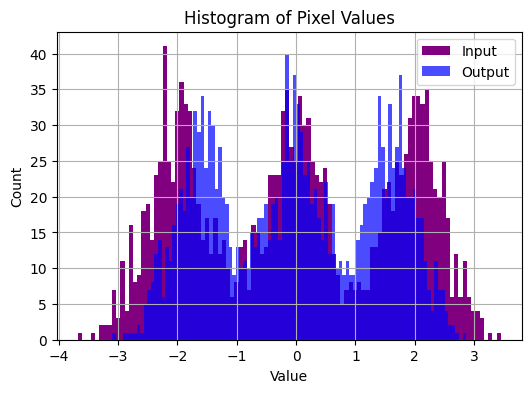

In [8]:
plot_value_histogram(X_train, y_train)

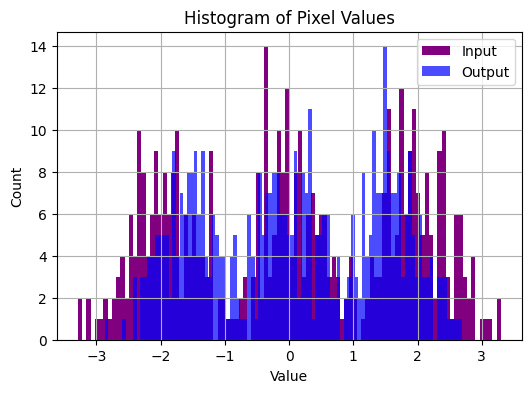

In [9]:
plot_value_histogram(X_test, y_test)

In [10]:
# Create model
model = NoiseConditionedNet(
    input_channels=1,  # Single channel input
    hidden_channels=32,  # Hidden channels
    embed_dim=16,  # Noise embedding dimension
    output_channels=1,  # Single channel output
    n_ensemble=2,  # Number of ensemble members (fixed to 2 for this CRPS implementation)
)

# Setup optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [11]:
# Training loop
n_epochs = 4000
best_crps = float("inf")
crps_list = []
mse_list = []
best_model = None
for epoch in range(n_epochs):
    random_indices = torch.randperm(X_train.shape[0])
    loss = train_step(
        model, optimizer, X_train[random_indices], y_train[random_indices]
    )

    with torch.no_grad():
        predictions = model(X_train[random_indices])
        crps = crps_loss(predictions, y_train[random_indices])
        mse = mse_loss(predictions.mean(dim=1), y_train[random_indices])

    crps_list.append(crps)
    mse_list.append(mse)

    print(f"Epoch {epoch + 1}, Loss: {loss:.4f}, CRPS: {crps:.4f}, MSE: {mse:.4f}")

    if crps < best_crps:
        best_crps = crps
        best_model_state_dict = model.state_dict()
        print("New best CRPS: ", best_crps)
    print("--------------------------------")

Epoch 1, Loss: 1.1537, CRPS: 1.1187, MSE: 1.7227
New best CRPS:  tensor(1.1187)
--------------------------------
Epoch 2, Loss: 1.1186, CRPS: 1.0840, MSE: 1.6250
New best CRPS:  tensor(1.0840)
--------------------------------
Epoch 3, Loss: 1.0839, CRPS: 1.0494, MSE: 1.5310
New best CRPS:  tensor(1.0494)
--------------------------------
Epoch 4, Loss: 1.0493, CRPS: 1.0152, MSE: 1.4420
New best CRPS:  tensor(1.0152)
--------------------------------
Epoch 5, Loss: 1.0150, CRPS: 0.9814, MSE: 1.3558
New best CRPS:  tensor(0.9814)
--------------------------------
Epoch 6, Loss: 0.9823, CRPS: 0.9480, MSE: 1.2743
New best CRPS:  tensor(0.9480)
--------------------------------
Epoch 7, Loss: 0.9478, CRPS: 0.9153, MSE: 1.1984
New best CRPS:  tensor(0.9153)
--------------------------------
Epoch 8, Loss: 0.9142, CRPS: 0.8843, MSE: 1.1284
New best CRPS:  tensor(0.8843)
--------------------------------
Epoch 9, Loss: 0.8836, CRPS: 0.8517, MSE: 1.0587
New best CRPS:  tensor(0.8517)
----------------

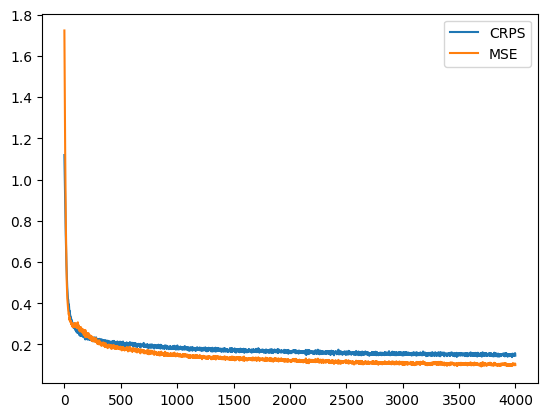

In [12]:
plt.plot(crps_list, label="CRPS")
plt.plot(mse_list, label="MSE")
plt.legend()
plt.show()

In [13]:
# Eval on test set
best_model = NoiseConditionedNet(
    input_channels=1,  # Single channel input
    hidden_channels=32,  # Hidden channels
    embed_dim=16,  # Noise embedding dimension
    output_channels=1,  # Single channel output
    n_ensemble=2,  # Number of ensemble members (fixed to 2 for this CRPS implementation)
)
best_model.load_state_dict(best_model_state_dict)
with torch.no_grad():
    predictions = best_model(X_test)
    print("CRPS Test: ", crps_loss(predictions, y_test))
    print("MSE Test: ", mse_loss(predictions.mean(dim=1), y_test))

CRPS Test:  tensor(0.2932)
MSE Test:  tensor(0.2508)


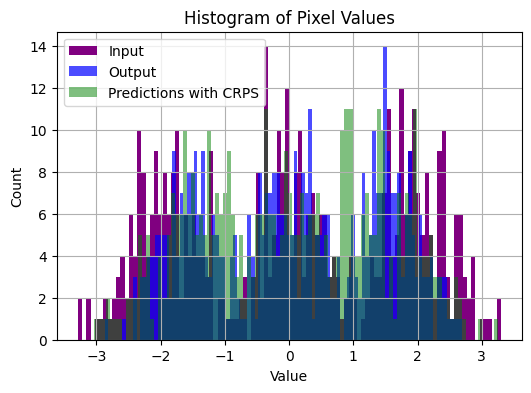

In [14]:
plot_value_histogram(X_test, y_test, predictions[:, 1], "Predictions with CRPS")

In [15]:
# Deterministic Model
model_without_noise = Net(
    input_channels=1,
    hidden_channels=32,
    embed_dim=16,
    output_channels=1,
)

optimizer_without_noise = torch.optim.Adam(model_without_noise.parameters(), lr=1e-3)

In [16]:
# Training loop
n_epochs = 4000
best_mse = float("inf")
crps_list = []
mse_list = []
best_model = None
for epoch in range(n_epochs):
    random_indices = torch.randperm(X_train.shape[0])
    loss = train_step(
        model_without_noise,
        optimizer_without_noise,
        X_train[random_indices],
        y_train[random_indices],
        mse=True,
    )

    with torch.no_grad():
        prediction = model_without_noise(X_train[random_indices])
        mse = mse_loss(prediction, y_train[random_indices])
        predictions = torch.stack([prediction, prediction], dim=1)
        crps = crps_loss(predictions, y_train[random_indices])

    crps_list.append(crps)
    mse_list.append(mse)

    print(f"Epoch {epoch + 1}, Loss: {loss:.4f}, CRPS: {crps:.4f}, MSE: {mse:.4f}")

    if mse < best_mse:
        best_mse = mse
        best_model_without_noise_state_dict = model_without_noise.state_dict()
        print("New best MSE: ", best_mse)
    print("--------------------------------")

/pscratch/sd/s/suryad/conda_envs/emulator_scratch/lib/python3.10/site-packages/torch/nn/modules/instancenorm.py:80: UserWarning: input's size at dim=1 does not match num_features. You can silence this warning by not passing in num_features, which is not used because affine=False
  warnings.warn(f"input's size at dim={feature_dim} does not match num_features. "


Epoch 1, Loss: 2.0497, CRPS: 1.3091, MSE: 2.3178
New best MSE:  tensor(2.3178)
--------------------------------
Epoch 2, Loss: 2.0280, CRPS: 1.2931, MSE: 2.2618
New best MSE:  tensor(2.2618)
--------------------------------
Epoch 3, Loss: 2.0151, CRPS: 1.2765, MSE: 2.2049
New best MSE:  tensor(2.2049)
--------------------------------
Epoch 4, Loss: 2.0065, CRPS: 1.2600, MSE: 2.1491
New best MSE:  tensor(2.1491)
--------------------------------
Epoch 5, Loss: 1.9993, CRPS: 1.2439, MSE: 2.0957
New best MSE:  tensor(2.0957)
--------------------------------
Epoch 6, Loss: 1.9926, CRPS: 1.2287, MSE: 2.0456
New best MSE:  tensor(2.0456)
--------------------------------
Epoch 7, Loss: 1.9864, CRPS: 1.2147, MSE: 2.0001
New best MSE:  tensor(2.0001)
--------------------------------
Epoch 8, Loss: 1.9813, CRPS: 1.2023, MSE: 1.9602
New best MSE:  tensor(1.9602)
--------------------------------
Epoch 9, Loss: 1.9776, CRPS: 1.1918, MSE: 1.9269
New best MSE:  tensor(1.9269)
-------------------------

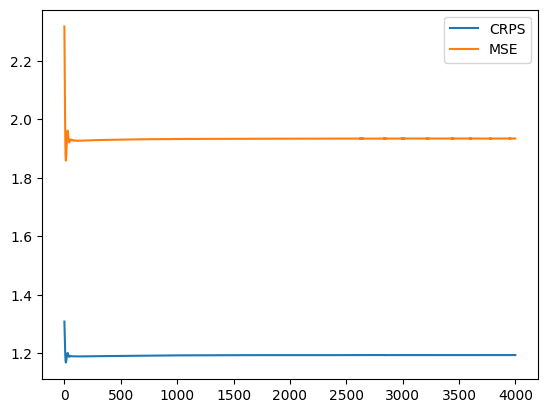

In [17]:
import matplotlib.pyplot as plt

plt.plot(crps_list, label="CRPS")
plt.plot(mse_list, label="MSE")
plt.legend()
plt.show()

In [18]:
# Eval on test set
best_model_without_noise = Net(
    input_channels=1,
    hidden_channels=32,
    embed_dim=16,
    output_channels=1,
)
best_model_without_noise.load_state_dict(best_model_without_noise_state_dict)
with torch.no_grad():
    prediction = best_model_without_noise(X_test)
    print("MSE Test: ", mse_loss(prediction, y_test))
    predictions = torch.stack([prediction, prediction], dim=1)
    print("CRPS Test: ", crps_loss(predictions, y_test))

MSE Test:  tensor(1.8936)
CRPS Test:  tensor(1.1857)


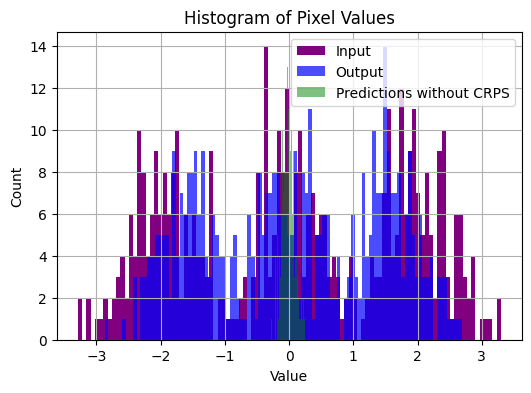

In [19]:
plot_value_histogram(X_test, y_test, prediction, "Predictions without CRPS")

#### Testing CRPS with ensemble > 2

In [ ]:
def compute_crps(
    target: torch.Tensor,
    prediction: torch.Tensor,
    sample_dim: int = 1,
) -> torch.Tensor:
    """
    CRPS is defined for one-dimensional random variables as.

        CRPS(F, x) = integral_z (F(z) - H(z - x))^2 dz

    where $F(x)$ is the cumulative distribution function (CDF) of the forecast
    distribution $F$ and $H(x)$ denotes the Heaviside step function, where $x$
    is an observation.

    This implementation is based on the identity:

        CRPS(F, x) = E_F|X - x| - 1/2 * E_F|X - X'|

    where X and X' denote independent random variables drawn from the forecast
    distribution F, and E_F denotes the expectation value under F.

    This reference (but not the implementation) is taken from the
    Proper Scoring repository [1]_. It can also be found on Wikipedia [2]_
    and is taken originally from Gneiting and Raftery (2007) [3]_ Equation 21.

    Args:
        target: The target tensor without a sample dimension
        prediction: The prediction tensor with a sample dimension
        sample_dim: The dimension of `prediction` corresponding to sample.

    .. [1] https://github.com/properscoring/properscoring/blob/master/properscoring/_crps.py
    .. [2] https://en.wikipedia.org/wiki/Scoring_rule
    .. [3] https://sites.stat.washington.edu/people/raftery/Research/PDF/Gneiting2007jasa.pdf
    """  # noqa: E501
    sample_mae_estimate = get_sample_mae_estimate(prediction, sample_dim)
    truth_mae: torch.tensor = torch.abs(target - prediction).mean(axis=sample_dim)
    return truth_mae - 0.5 * sample_mae_estimate


def get_sample_mae_estimate(prediction: torch.Tensor, sample_dim: int = 1):
    n_samples = prediction.shape[sample_dim]
    out_shape = list(prediction.shape)
    out_shape.pop(sample_dim)
    if n_samples == 1:
        return torch.full(
            out_shape,
            fill_value=torch.nan,
            device=prediction.device,
            dtype=prediction.dtype,
        )
    else:
        sample_mae_estimate = torch.zeros(
            out_shape, device=prediction.device, dtype=prediction.dtype
        )
        for i in range(1, n_samples):
            sample_mae_estimate += torch.abs(
                prediction - torch.roll(prediction, shifts=i, dims=sample_dim)
            ).mean(axis=sample_dim)
        sample_mae_estimate /= n_samples - 1
    return sample_mae_estimate

In [147]:
x = torch.tensor([1, 2, 3])
pair_counts = {}
for i in range(1, x.shape[0]):
    print("x ORG", x)
    print("x ROL", x.roll(shifts=i, dims=0))
    # Get pairs of adjacent values from x and rolled x, sorting within each pair
    pairs = [
        tuple(sorted([a.item(), b.item()])) for a, b in zip(x, x.roll(shifts=i, dims=0))
    ]
    # Count instances of each pair and store in dictionary
    for pair in sorted(pairs):
        if pair not in pair_counts:
            pair_counts[pair] = 0
        pair_counts[pair] += 1
    print(pair_counts)

x ORG tensor([1, 2, 3, 4, 5])
x ROL tensor([5, 1, 2, 3, 4])
{(1, 2): 1, (1, 5): 1, (2, 3): 1, (3, 4): 1, (4, 5): 1}
x ORG tensor([1, 2, 3, 4, 5])
x ROL tensor([4, 5, 1, 2, 3])
{(1, 2): 1, (1, 5): 1, (2, 3): 1, (3, 4): 1, (4, 5): 1, (1, 3): 1, (1, 4): 1, (2, 4): 1, (2, 5): 1, (3, 5): 1}
x ORG tensor([1, 2, 3, 4, 5])
x ROL tensor([3, 4, 5, 1, 2])
{(1, 2): 1, (1, 5): 1, (2, 3): 1, (3, 4): 1, (4, 5): 1, (1, 3): 2, (1, 4): 2, (2, 4): 2, (2, 5): 2, (3, 5): 2}
x ORG tensor([1, 2, 3, 4, 5])
x ROL tensor([2, 3, 4, 5, 1])
{(1, 2): 2, (1, 5): 2, (2, 3): 2, (3, 4): 2, (4, 5): 2, (1, 3): 2, (1, 4): 2, (2, 4): 2, (2, 5): 2, (3, 5): 2}


In [ ]:
cc = compute_crps(y.unsqueeze(1), predictions).mean()
cl = crps_loss(predictions, y, alpha=1.00)

assert cc == cl

In [154]:
import dataclasses


@dataclasses.dataclass
class CRPSExperiment:
    name: str
    truth_amount: float
    random_amount: float


def test_crps():
    nx = 1
    ny = 1
    n_batch = 1000
    n_sample = 2
    truth_amount = 0.8
    random_amount = 0.5
    experiments = [
        CRPSExperiment("perfect", truth_amount, random_amount),
        CRPSExperiment("extra_variance", truth_amount, random_amount * 1.1),
        CRPSExperiment("less_variance", truth_amount, random_amount * 0.9),
        CRPSExperiment("deterministic", truth_amount, random_amount * 1e-5),
    ]
    torch.manual_seed(890)
    x_predictable = torch.rand(n_batch, nx, ny)
    x = truth_amount * x_predictable + random_amount * torch.rand(n_batch, nx, ny)
    crps_values = {}
    for experiment in experiments:
        x_sample = experiment.truth_amount * x_predictable.unsqueeze(
            1
        ) + experiment.random_amount * torch.rand(n_batch, n_sample, nx, ny)
        crps_values[experiment.name] = crps_loss(x_sample, x)

    print(f"Perfect: {crps_values['perfect']}")
    print(f"Extra variance: {crps_values['extra_variance']}")
    print(f"Less variance: {crps_values['less_variance']}")
    print(f"Deterministic: {crps_values['deterministic']}")
    assert crps_values["perfect"] < crps_values["extra_variance"]
    assert crps_values["perfect"] < crps_values["less_variance"]
    assert crps_values["extra_variance"] < crps_values["deterministic"]
    assert crps_values["less_variance"] < crps_values["deterministic"]

In [155]:
test_crps()

Perfect: 0.08296459913253784
Extra variance: 0.0839855819940567
Less variance: 0.09018474072217941
Deterministic: 0.2572580873966217
